# Scary Stochastics, Week 2: Poisson Processes
## Notebook 3 of 3 — Queueing & Backlogs

Also self-contained. Each house is a mini service point: arrivals (from Notebooks 1-2) vs. a service rate (how fast that house can greet a treater). When arrivals outpace service, a line forms — this notebook finds where and when.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Trick-or-treat palette (extends the harvest palette with candy red + goblin green)
PALETTE = {
    "red":    "#C8102E",  # candy red
    "orange": "#E8741C",  # pumpkin orange
    "rust":   "#B5451B",  # burnt orange/rust
    "purple": "#3B2145",  # deep purple
    "mustard":"#D9A404",  # mustard gold
    "green":  "#3F7A3F",  # goblin green
    "black":  "#1B1B1B",
    "cream":  "#FBF3E1",
}

CANDY_TYPES = ["Full-size", "Fun-size", "Pretzels", "Chips", "Fruit"]
CANDY_COLORS = [PALETTE["red"], PALETTE["orange"], PALETTE["mustard"], PALETTE["purple"], PALETTE["green"]]

N_HOUSES = 25
EVENING_START, EVENING_END = 0, 180  # minutes since 6:00 PM (evening runs 6:00-9:00 PM)

def minute_to_clock(m):
    """Convert minutes-since-6:00-PM into a clock label, e.g. 90 -> '7:30 PM'."""
    total = 18 * 60 + int(m)
    hh, mm = (total // 60) % 24, total % 60
    period = "AM" if hh < 12 else "PM"
    hh12 = hh % 12
    hh12 = 12 if hh12 == 0 else hh12
    return f"{hh12}:{mm:02d} {period}"

plt.rcParams.update({
    "figure.facecolor": PALETTE["cream"],
    "axes.facecolor": PALETTE["cream"],
    "axes.edgecolor": PALETTE["black"],
    "text.color": PALETTE["black"],
    "axes.labelcolor": PALETTE["black"],
    "xtick.color": PALETTE["black"],
    "ytick.color": PALETTE["black"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

In [2]:
# 25 houses on the street, each with a popularity level, a candy archetype,
# and a service rate (how many treaters per minute they can greet)
house_ids = np.arange(1, N_HOUSES + 1)

popularity = np.random.uniform(0.5, 2.5, N_HOUSES)
archetype = np.random.choice(CANDY_TYPES, size=N_HOUSES, p=[0.15, 0.35, 0.2, 0.15, 0.15])

# Generous houses (full-size bars) take longer per treater than a quick fruit hand-out
BASE_SERVICE = {"Full-size": 0.4, "Fun-size": 3.0, "Pretzels": 2.3, "Chips": 2.6, "Fruit": 4.0}
service_rate = np.array([BASE_SERVICE[a] * np.random.uniform(0.85, 1.15) for a in archetype])

houses_df = pd.DataFrame({
    "House": house_ids,
    "Popularity": popularity.round(2),
    "Archetype": archetype,
    "ServiceRate_per_min": service_rate.round(2),
})
houses_df.head()

,House,Popularity,Archetype,ServiceRate_per_min
0,1,1.25,Chips,2.97
1,2,2.40,Fun-size,3.25
2,3,1.96,Pretzels,2.60
3,4,1.70,Pretzels,2.57
4,5,0.81,Full-size,0.41


In [3]:
def base_rate(t):
    """Street-wide base arrival rate (treaters/min) before house popularity scaling.
    Non-homogeneous: rises toward a dusk peak, then tapers off."""
    peak_t, width, peak_rate = 90, 40, 0.18
    return peak_rate * np.exp(-0.5 * ((t - peak_t) / width) ** 2)

def simulate_nhpp(popularity_i, t_start=EVENING_START, t_end=EVENING_END):
    """Simulate one house's arrivals via thinning (non-homogeneous Poisson process)."""
    lam_max = popularity_i * 0.18  # 0.18 is base_rate's peak value
    t, arrivals = t_start, []
    while t < t_end:
        t += np.random.exponential(1 / lam_max)
        if t < t_end and np.random.uniform() < (popularity_i * base_rate(t)) / lam_max:
            arrivals.append(t)
    return np.array(arrivals)

def candy_probs_for(archetype_label):
    """A house mostly hands out its archetype candy, with a little variety mixed in."""
    probs = np.full(len(CANDY_TYPES), 0.075)
    probs[CANDY_TYPES.index(archetype_label)] = 0.7
    return probs / probs.sum()

records = []
for _, row in houses_df.iterrows():
    arrivals = simulate_nhpp(row["Popularity"])
    probs = candy_probs_for(row["Archetype"])
    candies = np.random.choice(CANDY_TYPES, size=len(arrivals), p=probs)
    for t, c in zip(arrivals, candies):
        records.append((row["House"], t, c))

arrivals_df = pd.DataFrame(records, columns=["House", "ArrivalMin", "CandyType"])
arrivals_df.head()

,House,ArrivalMin,CandyType
0,1,20.422139,Chips
1,1,35.140551,Chips
2,1,35.647962,Chips
3,1,40.144538,Chips
4,1,44.576431,Chips


### Visual 5 — Service time by house

Generous houses (full-size candy bars) take longer per treater than a quick fruit hand-out — bar color shows each house's archetype.

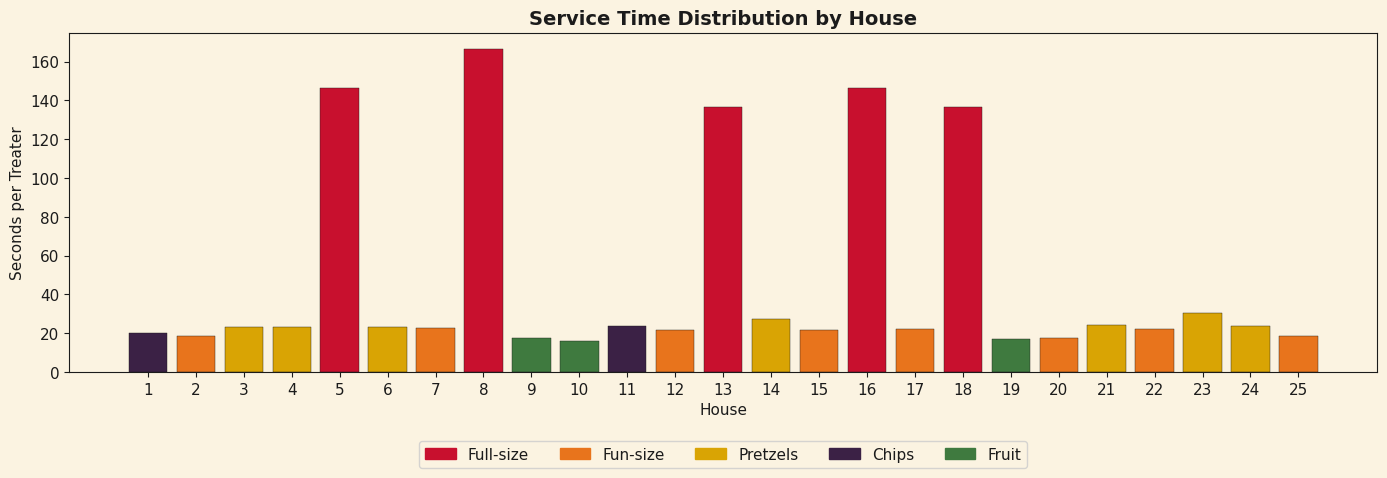

In [4]:
service_time_sec = 60 / houses_df["ServiceRate_per_min"]
color_lookup = dict(zip(CANDY_TYPES, CANDY_COLORS))
bar_colors = houses_df["Archetype"].map(color_lookup)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(houses_df["House"], service_time_sec, color=bar_colors,
       edgecolor=PALETTE["black"], linewidth=0.3)
ax.set_xticks(house_ids)
ax.set_xlabel("House")
ax.set_ylabel("Seconds per Treater")
ax.set_title("Service Time Distribution by House")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CANDY_COLORS]
ax.legend(handles, CANDY_TYPES, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.savefig("05_service_time.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 6 — Which houses are at backlog risk?

Utilization ρ = peak arrival rate ÷ service rate. ρ ≥ 1 means arrivals outpace service at peak — a queue is expected to form.

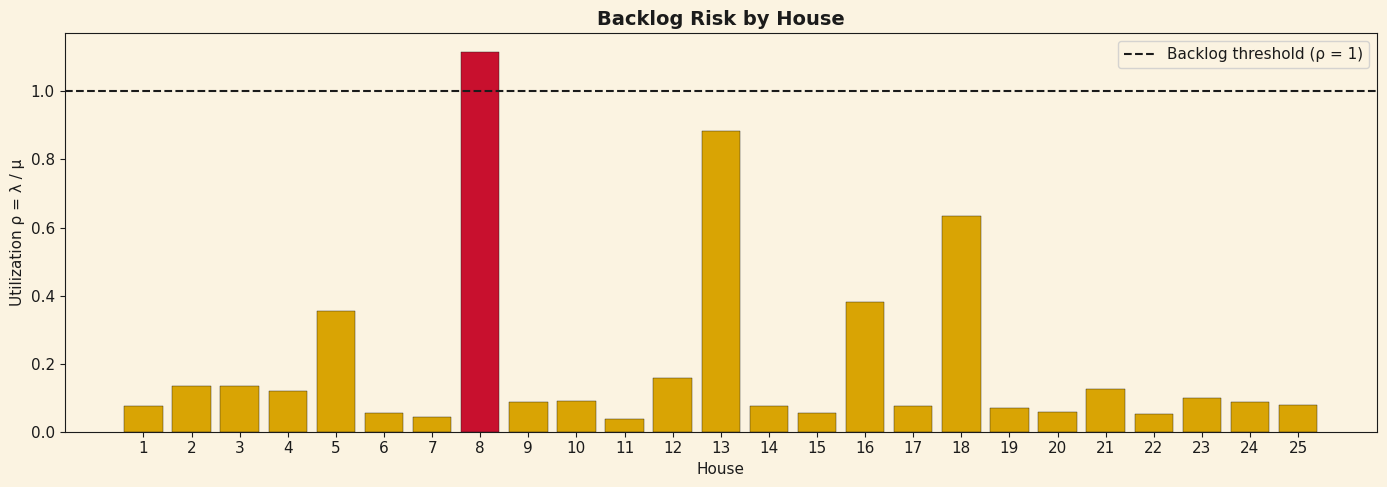

In [5]:
PEAK_RATE = 0.18
lambda_peak = houses_df["Popularity"] * PEAK_RATE
rho = lambda_peak / houses_df["ServiceRate_per_min"]

bar_colors = [PALETTE["red"] if r >= 1 else PALETTE["mustard"] for r in rho]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(houses_df["House"], rho, color=bar_colors, edgecolor=PALETTE["black"], linewidth=0.3)
ax.axhline(1.0, color=PALETTE["black"], linestyle="--", linewidth=1.5,
           label="Backlog threshold (ρ = 1)")
ax.set_xticks(house_ids)
ax.set_xlabel("House")
ax.set_ylabel("Utilization ρ = λ / μ")
ax.set_title("Backlog Risk by House")
ax.legend()
plt.tight_layout()
plt.savefig("06_backlog_risk.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Visual 7 — When and where backlogs actually form

Binning the evening into 15-minute windows, each house's queue carries over from one window to the next: `backlog = max(backlog + arrivals - capacity, 0)`.

**Note on reading this against Visual 6:** this heatmap is *one* simulated evening, while Visual 6's ρ is an expected-value calculation. A house with ρ just over 1 (like House 8) is only slightly overloaded at its single peak moment, so whether it visibly backs up on any given night comes down to the Poisson randomness of that night's arrivals — it might not be the house that queues here, even though it's the riskiest on average. Re-running the simulation cells above will reshuffle which house backs up on a given run.

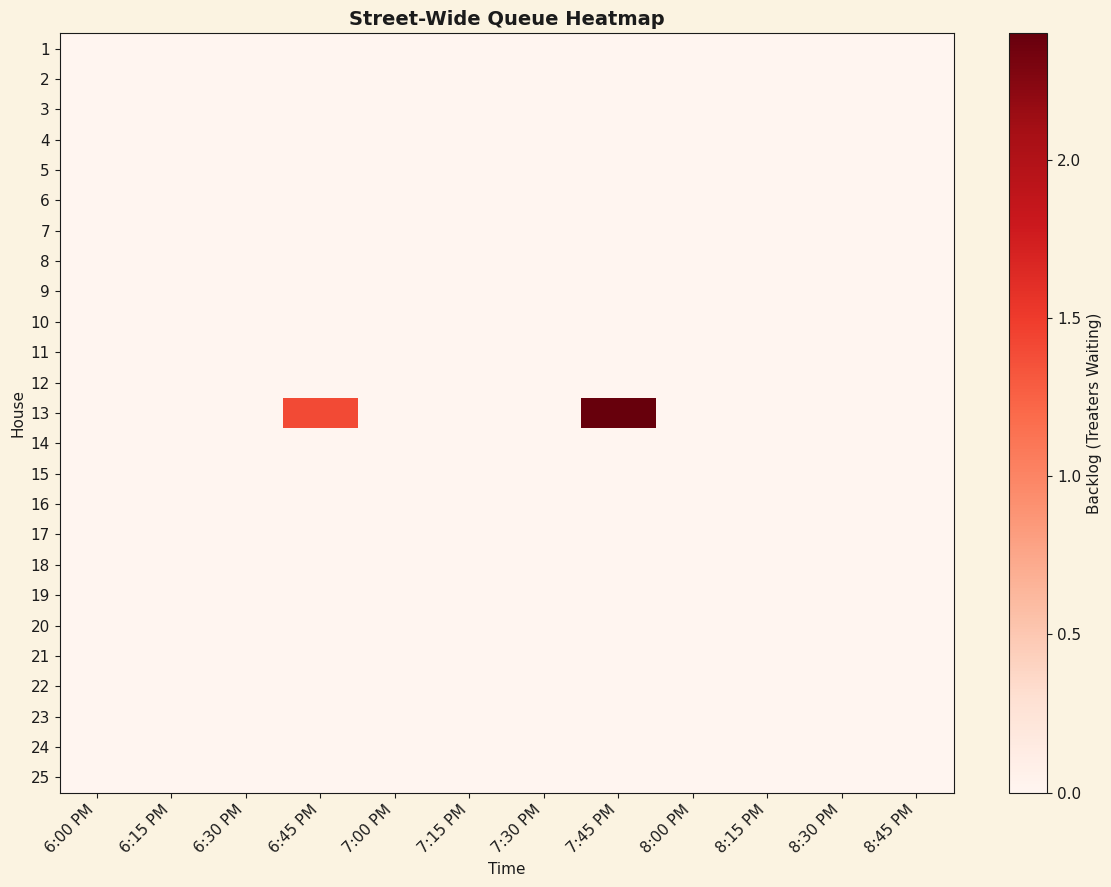

In [6]:
BIN_WIDTH = 15  # minutes
bin_edges = np.arange(EVENING_START, EVENING_END + BIN_WIDTH, BIN_WIDTH)
bin_labels = bin_edges[:-1]

arrivals_df["Bin"] = pd.cut(arrivals_df["ArrivalMin"], bins=bin_edges, labels=bin_labels, right=False)
arrival_counts = (
    arrivals_df.groupby(["House", "Bin"], observed=True).size()
    .unstack(fill_value=0)
    .reindex(index=house_ids, columns=bin_labels, fill_value=0)
)

capacity_per_bin = houses_df.set_index("House")["ServiceRate_per_min"] * BIN_WIDTH

queue = pd.DataFrame(0.0, index=house_ids, columns=bin_labels)
backlog = np.zeros(N_HOUSES)
for b in bin_labels:
    backlog = np.maximum(backlog + arrival_counts[b].values - capacity_per_bin.values, 0)
    queue[b] = backlog

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(queue.values, cmap="Reds", aspect="auto")
ax.set_yticks(range(N_HOUSES)); ax.set_yticklabels(house_ids)
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels([minute_to_clock(m) for m in bin_labels], rotation=45, ha="right")
ax.set_xlabel("Time")
ax.set_ylabel("House")
ax.set_title("Street-Wide Queue Heatmap")
plt.colorbar(im, label="Backlog (Treaters Waiting)")
plt.tight_layout()
plt.savefig("07_queue_heatmap.png", dpi=150, facecolor=PALETTE["cream"])
plt.show()

### Up next

Week 3 moves to Brownian Motion, modeling a 'haunted market crash' with real stock price data.